In [1]:
import h5py
import numpy as np
import json
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18
})

In [4]:
file_path = "pbhs/network_pbh_CE40_1p5MW_Aplus_coat_5.0hz_CE20_1p5MW_Aplus_coat_5.0hz_ET_triangle_5.0hz.h5" 

print(f"Opening {file_path}...\n")

with h5py.File(file_path, 'r') as f:
    
    # ---------------------------------------------------------
    # READ THE METADATA (Attributes)
    # ---------------------------------------------------------
    # Attributes are accessed via f.attrs
    detectors = f.attrs['detectors'].split(',')
    net_snr_th = f.attrs['snr_threshold']
    n_total = f.attrs['total_events']
    n_detected = f.attrs['detected_events']
    par_dict = json.loads(f.attrs['event_parameters'])

    print(f"Network: {detectors}")
    print(f"Thresholds: Net SNR > {net_snr_th}")
    print(f"Detected: {n_detected} / {n_total} events\n")
    print(par_dict)

    # ---------------------------------------------------------
    # READ THE DATA ARRAYS
    # ---------------------------------------------------------
    
    snr_net = f['snr'][:]
    sky_areas = f['sky_area_90'][:]        # Shape: (N_events,)
    fisher_net = f['fisher'][:]            # Shape: (N_events, n_parameters, n_parameters)
    cov_net = f['covariance'][:]           # Shape: (N_events, n_parameters, n_parameters)
    connd_nums = f['condition_numbers'][:]
    inv_errors = f['inversion_errors'][:]
    
    # Load the boolean flags for filtering
    part_matrix = f['is_in_band'][:]
    detected_mask = f['is_detected'][:]

Opening pbhs/network_pbh_CE40_1p5MW_Aplus_coat_5.0hz_CE20_1p5MW_Aplus_coat_5.0hz_ET_triangle_5.0hz.h5...

Network: ['CE40_1p5MW_Aplus_coat', 'CE20_1p5MW_Aplus_coat', 'ET_triangle']
Thresholds: Net SNR > 10.0
Detected: 307 / 600 events

{'Mc': 0, 'eta': 1, 'dL': 2, 'theta': 3, 'phi': 4, 'iota': 5, 'psi': 6, 'tcoal': 7, 'Phicoal': 8, 'chi1z': 9, 'chi2z': 10}


In [5]:
# ---------------------------------------------------------
# HOW TO FILTER YOUR DATA FOR PLOTTING
# ---------------------------------------------------------

# Extract the SNRs and Sky Areas only for the detected events
snr_detected = snr_net[detected_mask]

# Extract the fractional distance error (assuming dL is parameter index 2)
# errors[:, 2] gives the absolute error in Gpc. 
# You'd need to divide by the true dL from your master catalog to get fractional.
#dL_errors_detected = errors[detected_mask, 2] 

print("--- Analysis of Detected Events ---")
print(f"Median Network SNR: {np.median(snr_detected):.2f}")
print(f"Median 90% Sky Area: {np.median(sky_areas):.4f} sq deg")

--- Analysis of Detected Events ---
Median Network SNR: 25.22
Median 90% Sky Area: 97.3355 sq deg


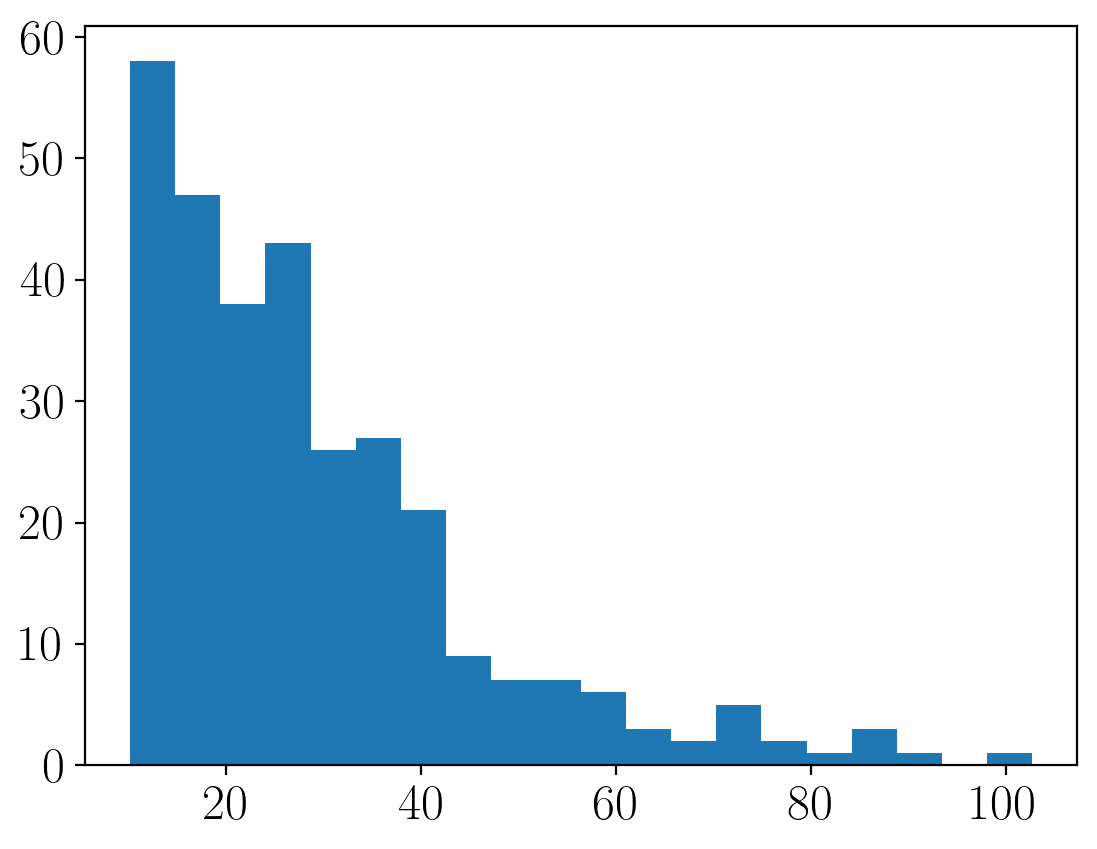

In [13]:
plt.hist(snr_detected, bins=20);

In [14]:
# Loading events
event_file = '/Users/lucareali/Downloads/baltimore/research/CE_STM_CBC/pop_models/pbh/PBH_cat_1yr.h5'
with h5py.File(event_file, 'r') as f:
    events = {key: f[key][:] for key in f.keys()}

In [20]:
is_all_detectors_mask = np.all(part_matrix, axis=1)
strict_mask = is_all_detectors_mask & detected_mask

In [23]:
np.sum(strict_mask)

307

In [33]:
import astropy.units as u
from astropy.cosmology import Planck18 # Or whichever cosmology you used to generate the catalog

# Load your true redshifts from the master catalog
z_true = events['z'][strict_mask]

# Extract your absolute dL errors from the network HDF5 file
dL_errors_Gpc = np.sqrt(np.maximum(0, cov_net[2, 2, :] ))

def convert_dL_error_to_z_error(z, delta_dL, cosmo=Planck18):
    """
    Converts absolute errors in dL (in Gpc) to absolute errors in redshift.
    """
    # Speed of light in km/s
    c = 299792.458 * (u.km / u.s)
    
    # Calculate H(z) in km/s/Mpc and dL(z) in Gpc for your specific events
    H_z = cosmo.H(z)
    dL_z = cosmo.luminosity_distance(z).to(u.Gpc)
    
    # Calculate the two terms of the derivative
    term1 = dL_z / (1 + z)
    term2 = (c * (1 + z) / H_z).to(u.Gpc) # Ensure units match!
    
    # d(dL)/dz in Gpc per unit redshift
    ddL_dz = term1 + term2
    
    # Project the error
    delta_z = delta_dL / ddL_dz.value
    
    return delta_z

# 3. Apply the vectorized function to your arrays
delta_z_array = convert_dL_error_to_z_error(z_true, dL_errors_Gpc)

In [34]:
Mtot = events['m1_src'] + events['m2_src']
Mtot_true = Mtot[strict_mask]

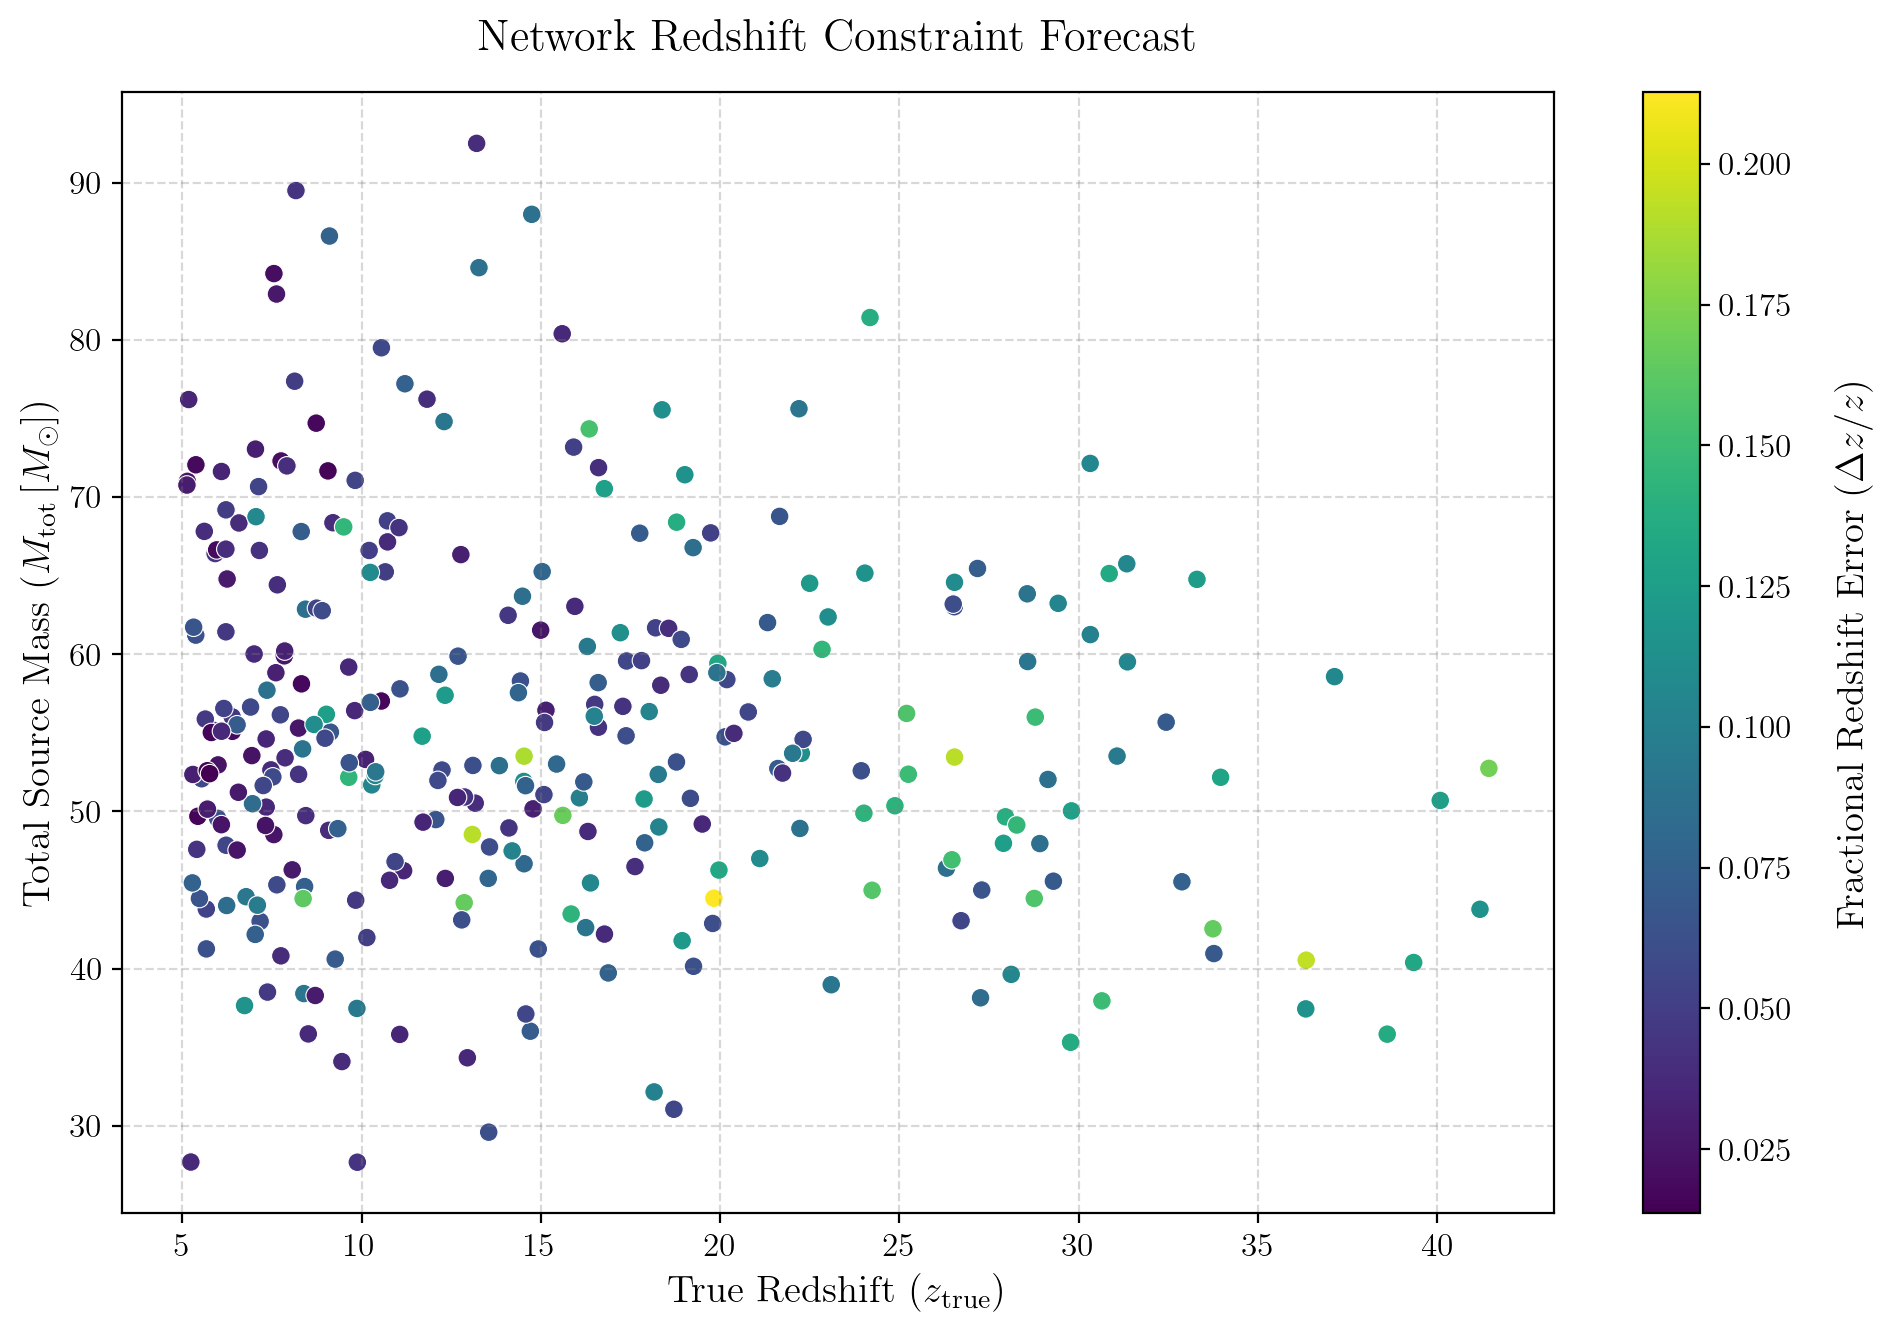

In [46]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. Set up a well-proportioned figure
plt.figure(figsize=(10, 7))

# 2. Plot with advanced formatting
sc = plt.scatter(
    z_true, 
    Mtot_true, 
    c=delta_z_array / z_true, 
    cmap='viridis',             # A perceptually uniform colormap
    s=45,                       # Slightly larger marker size
    alpha=1.,                 # Transparency to reveal overlapping events
    edgecolors='white',         # White borders separate overlapping points
    linewidth=0.4,
#    norm=colors.LogNorm(        # Logarithmic color scale!
#        vmin=1e-3,              # Set the color floor (e.g., 0.1% error)
#        vmax=1.0                # Set the color ceiling (e.g., 100% error)
#    ) 
)

# 4. Add a descriptive Colorbar
cbar = plt.colorbar(sc)
cbar.set_label(r'Fractional Redshift Error ($\Delta z / z$)', fontsize=14, labelpad=15)
cbar.ax.tick_params(labelsize=12)

# 5. Add proper axis labels with LaTeX formatting
plt.xlabel(r'True Redshift ($z_{\mathrm{true}}$)', fontsize=14)
plt.ylabel(r'Total Source Mass ($M_{\mathrm{tot}} \, [M_\odot]$)', fontsize=14)

# 6. Title and subtle grid
plt.title('Network Redshift Constraint Forecast', fontsize=16, pad=15)
plt.grid(True, which="both", ls="--", alpha=0.3, color='gray')

# 7. Tweak tick sizes for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 8. Prevent clipping and show
plt.tight_layout()
plt.show()

In [54]:
mask_error = delta_z_array/z_true < 0.2 
mask_z = z_true > 25
mask_both = mask_error & mask_z

In [ ]:
np.sum(mask_both)

47